### PART1 VectorDB : 상품의미검색
- 상품설명을 임베딩해서 맥락 기반의 검색 수행
### PART2 GraphDB : 구매/리뷰 
- 유저-상품-리뷰간의 그래프생성 및 분석
### PART3 GraphRAG & 추천
- 의미검색결과에서 신뢰도(그래프 중심성)높은 상품 필터링

In [4]:
import chromadb
from chromadb.utils import embedding_functions
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

products = [
    {"id": "p1", "name": "프로그래밍용 고성능 노트북", "desc": "최신 14세대 CPU와 32GB RAM을 탑재하여 무거운 딥러닝 및 개발 작업에 최적화된 랩탑입니다.", "category": "가전"},
    {"id": "p2", "name": "초경량 사무용 랩탑", "desc": "1kg 미만의 가벼운 무게로 카페나 도서관에서 문서 작업 및 웹서핑을 하기에 매우 좋은 노트북.", "category": "가전"},
    {"id": "p3", "name": "전문가용 미러리스 카메라", "desc": "4K 60fps 동영상 촬영과 빠르고 정확한 AF를 지원하여 유튜버 및 프로 사진작가에게 적합한 카메라.", "category": "가전"},
    {"id": "p4", "name": "편안한 러닝화", "desc": "쿠셔닝이 뛰어나고 통풍이 잘 되어 장시간 달리기나 헬스장 운동 시 발의 피로를 최소화해주는 운동화.", "category": "패션"},
    {"id": "p5", "name": "방수 트레킹화", "desc": "고어텍스 소재로 비오는 날이나 거친 산악 지형에서도 발을 쾌적하게 보호하는 등산용 신발.", "category": "패션"}
]

In [5]:
# 1. Chroma 인메모리 클라이언트 및 다국어 임베딩 설정
client = chromadb.Client()
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='paraphrase-multilingual-MiniLM-L12-v2'
)
# 기존 컬렉션 초기화 후 재생성
try:
    client.delete_collection('ecommerce')
except Exception:
    pass    
product_collection =  client.create_collection(
    name ='ecommerce',
    embedding_function=st_ef,
    metadata={'hnsw:space':'cosine'}
)
# 2. 가상의 이커머스 상품 데이터 (노트북, 카메라, 신발 등)
# 3. Vector DB에 데이터 삽입
product_collection.add(
    ids = [f'product_{i:03d}' for i, p in enumerate(products)],
    documents=[p['desc'] for p in products],
    metadatas=[
        { 'name':p['name'],'category':p['category']}
            for p in products        
    ]
)
# 4. 의미 기반 검색 테스트
query = '산에 갈 때 신기 좋은 튼튼한 신발'
results = product_collection.query(
    query_texts=[query],
    n_results=2  # top_2
)
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    similarity = 1- dist # 코사인거리->유사도 변환    
    print(similarity,doc,meta,dist)

0.785952091217041 고어텍스 소재로 비오는 날이나 거친 산악 지형에서도 발을 쾌적하게 보호하는 등산용 신발. {'name': '방수 트레킹화', 'category': '패션'} 0.21404790878295898
0.4105861186981201 쿠셔닝이 뛰어나고 통풍이 잘 되어 장시간 달리기나 헬스장 운동 시 발의 피로를 최소화해주는 운동화. {'name': '편안한 러닝화', 'category': '패션'} 0.5894138813018799


### 그래프 DB를 이용한 신뢰도 분석
- 제품검색은 VectorDB가 잘함
- 이 제품을 파는 판매자나 리뷰가 믿을만한가? ->관계데이터인 그래프DB가 유리
- 유저-상ㅍ무간의 구매 및 리뷰 그래프 모델링

In [6]:
# 그래프 생성
G = nx.DiGraph()
# 상품 노드추가(VectorDB id 사용)
for p in products:
    G.add_node( p['id'], type='Product' , name = p['name']  )

# 유저노드 추가
users = ['User_A','User_B','User_C',"Spammer_1","Spammer_2"]
for u in users:
    G.add_node(u, type='User', name=u)
# 구매 및 추천 관계 추가
# 정상유저들의 패턴 : 여러 상품을 구매하고 교류
edges = [
    ("User_A", "p5", "PURCHASED"), ("User_A", "p4", "PURCHASED"),
    ("User_B", "p5", "PURCHASED"), ("User_B", "p1", "PURCHASED"),
    ("User_C", "p1", "PURCHASED"), ("User_C", "p3", "PURCHASED"),
    ("User_A", "User_B", "FOLLOWS"), ("User_B", "User_C", "FOLLOWS")
]
# 사기패턴 : 특정 스패머들이 특정 상품(p2)만 집중적으로 가짜 구매/리뷰
spam_edges = [
    ("Spammer_1", "p2", "PURCHASED"), ("Spammer_2", "p2", "PURCHASED"),
    ("Spammer_1", "p2", "REVIEWED_5_STAR"), ("Spammer_2", "p2", "REVIEWED_5_STAR"),
    ("Spammer_1", "Spammer_2", "FOLLOWS") # 자기들끼리만 연결됨
]

for src,dst,rel in edges + spam_edges:
    G.add_edge(src,dst,type=rel)

print(f'그래프생성 완료 : 노드 : {G.number_of_nodes()}  엣지 : {G.number_of_edges()}')

그래프생성 완료 : 노드 : 10  엣지 : 11


In [7]:
# 페이지랭크(PageRnak)알고리즘 : 상품의 진짜 신뢰도 분석
raw_pr_scores = nx.pagerank(G, alpha=0.85)

suspicious_users = {n for n, data in G.nodes(data=True) if data['type'] == 'User' and str(n).startswith('Spammer')}
trusted_nodes = [n for n in G.nodes() if n not in suspicious_users]
trusted_G = G.subgraph(trusted_nodes).copy()
pr_scores = nx.pagerank(trusted_G, alpha=0.85)

print("원본 그래프 PageRank (스팸 영향 포함)")
print("-" * 50)
for node, score in sorted(raw_pr_scores.items(), key=lambda x: -x[1]):
    node_data = G.nodes[node]
    node_type = node_data['type']
    name = node_data['name']
    bar = '*' * int(score * 80)
    print(f"[{node_type}] {name[:12]:<12} | 점수: {score:.3f} {bar}")

print("\n신뢰도 보정 PageRank (Spammer 제외)")
print("-" * 50)
for node, score in sorted(pr_scores.items(), key=lambda x: -x[1]):
    node_data = trusted_G.nodes[node]
    node_type = node_data['type']
    name = node_data['name']
    bar = '*' * int(score * 80)
    print(f"[{node_type}] {name[:12]:<12} | 점수: {score:.3f} {bar}")

원본 그래프 PageRank (스팸 영향 포함)
--------------------------------------------------
[Product] 초경량 사무용 랩탑   | 점수: 0.174 *************
[Product] 프로그래밍용 고성능 노 | 점수: 0.128 **********
[Product] 방수 트레킹화      | 점수: 0.109 ********
[Product] 전문가용 미러리스 카메 | 점수: 0.104 ********
[User] Spammer_2    | 점수: 0.094 *******
[User] User_C       | 점수: 0.090 *******
[Product] 편안한 러닝화      | 점수: 0.085 ******
[User] User_B       | 점수: 0.085 ******
[User] User_A       | 점수: 0.066 *****
[User] Spammer_1    | 점수: 0.066 *****

신뢰도 보정 PageRank (Spammer 제외)
--------------------------------------------------
[Product] 프로그래밍용 고성능 노 | 점수: 0.175 **************
[Product] 방수 트레킹화      | 점수: 0.148 ***********
[Product] 전문가용 미러리스 카메 | 점수: 0.142 ***********
[User] User_C       | 점수: 0.123 *********
[Product] 편안한 러닝화      | 점수: 0.116 *********
[User] User_B       | 점수: 0.116 *********
[Product] 초경량 사무용 랩탑   | 점수: 0.090 *******
[User] User_A       | 점수: 0.090 *******


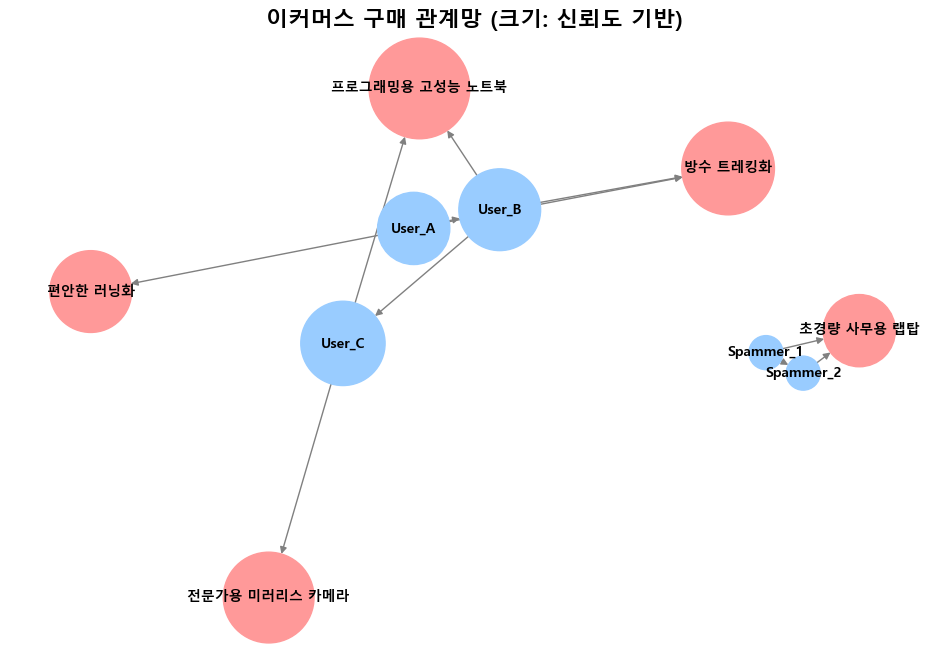

In [8]:
# 3. 그래프 시각화
fig, ax = plt.subplots(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 한글 라벨이 깨지지 않도록 폰트를 명시적으로 지정
label_font = 'Malgun Gothic'

# 노드 타입별 색상 지정
color_map = {'Product': '#FF9999', 'User': '#99CCFF'}
colors = [color_map[G.nodes[n]['type']] for n in G.nodes()]
sizes = [pr_scores.get(n, 0.02) * 30000 for n in G.nodes()] # 스팸 노드는 작은 기본 크기 사용

nx.draw(G, pos, with_labels=True, labels={n: G.nodes[n]['name'] for n in G.nodes()},
        node_color=colors, node_size=sizes, font_size=10, font_weight='bold', 
        font_family=label_font,
        edge_color='gray', arrows=True, ax=ax)
plt.title("이커머스 구매 관계망 (크기: 신뢰도 기반)", fontsize=16, fontweight='bold')
plt.show()


### part3 Vector DB + Graph DB

In [9]:
# 1. 사용자 질의
query = "카페에서 쓰기 좋은 코딩용 노트북"

# 2. Vector DB에서 1차 의미 검색 (Top 3)
results = product_collection.query(query_texts=[query], n_results=3)

print(" [1차 필터링] Vector DB 검색 결과 (의미 기반)")
print("-" * 50)
candidates = []
for doc, meta, dist, p_id in zip(results['documents'][0], results['metadatas'][0], results['distances'][0], results['ids'][0]):
    sim = 1 - dist
    candidates.append({"id": p_id, "name": meta['name'], "vector_score": sim})
    print(f"상품명: {meta['name']:<15} | Vector 유사도: {sim:.4f}")

# 3. Graph DB 신뢰도 융합 (Hybrid Scoring)
print("\n [최종 추천] Vector 유사도 + Graph 신뢰도 융합 결과")
print("-" * 50)

alpha = 0.6 # 벡터 유사도 비중
beta = 0.4  # 그래프 신뢰도 비중

for c in candidates:
    v_score = c['vector_score']
    # PageRank 점수 정규화 (가독성을 위해 10배 곱함)
    g_score = pr_scores.get(c['id'], 0) * 10 
    
    # 하이브리드 점수 산출
    final_score = (v_score * alpha) + (g_score * beta)
    c['final_score'] = final_score
    c['graph_score'] = g_score

# 최종 점수순 정렬
candidates.sort(key=lambda x: x['final_score'], reverse=True)

for i, c in enumerate(candidates):
    print(f"{i+1}위: {c['name']:<15}")
    print(f"    └ 합산 점수: {c['final_score']:.4f} (Vector: {c['vector_score']:.4f}, Graph: {c['graph_score']:.4f})")


 [1차 필터링] Vector DB 검색 결과 (의미 기반)
--------------------------------------------------
상품명: 초경량 사무용 랩탑      | Vector 유사도: 0.6709
상품명: 프로그래밍용 고성능 노트북  | Vector 유사도: 0.3848
상품명: 전문가용 미러리스 카메라   | Vector 유사도: 0.2273

 [최종 추천] Vector 유사도 + Graph 신뢰도 융합 결과
--------------------------------------------------
1위: 초경량 사무용 랩탑     
    └ 합산 점수: 0.4025 (Vector: 0.6709, Graph: 0.0000)
2위: 프로그래밍용 고성능 노트북 
    └ 합산 점수: 0.2309 (Vector: 0.3848, Graph: 0.0000)
3위: 전문가용 미러리스 카메라  
    └ 합산 점수: 0.1364 (Vector: 0.2273, Graph: 0.0000)
